# 04 - Estrategia de quiniela y resultados de la simulación

Lee los outputs del pipeline:
- `outputs/picks/quiniela_*.csv` (4 perfiles de riesgo)
- `outputs/simulations/*` (probabilidades agregadas Monte-Carlo)

Visualiza el bracket esperado, compara picks entre perfiles, y muestra los favoritos al título.

**Prerequisito**: haber corrido `export_quiniela_sheet.py` y `simulate_tournament.py`.

In [43]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUTS = ROOT / 'outputs'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

## Carga de las 4 quinielas

In [44]:
PROFILES = ['safe', 'balanced', 'aggressive', 'contrarian']
sheets = {p: pd.read_csv(OUTPUTS / 'picks' / f'quiniela_{p}.csv') for p in PROFILES}

for p, df in sheets.items():
    print(f'{p:12s}: {len(df)} picks  | distribución: {df["pick"].value_counts().to_dict()}  | confianza media: {df["confidence"].mean():.3f}')

safe        : 72 picks  | distribución: {'H': 37, 'A': 35}  | confianza media: 0.574
balanced    : 72 picks  | distribución: {'H': 34, 'A': 28, 'D': 10}  | confianza media: 0.546
aggressive  : 72 picks  | distribución: {'H': 48, 'A': 24}  | confianza media: 0.509
contrarian  : 72 picks  | distribución: {'A': 39, 'H': 33}  | confianza media: 0.167


## Comparación de picks por partido entre los 4 perfiles

Muestra los partidos donde los perfiles **difieren** — son los que tienen mayor valor estratégico.

In [45]:
merge_cols = ['team_a', 'team_b']
base = sheets['balanced'][merge_cols + ['p_home', 'p_draw', 'p_away']].copy()
for p in PROFILES:
    base[f'pick_{p}'] = sheets[p]['pick'].values

different = base[
    (base['pick_safe'] != base['pick_balanced'])
    | (base['pick_balanced'] != base['pick_aggressive'])
    | (base['pick_aggressive'] != base['pick_contrarian'])
]
print(f'Partidos donde difieren los perfiles: {len(different)} / {len(base)}')
print()
print(different.head(20).to_string(index=False))

Partidos donde difieren los perfiles: 72 / 72

       team_a             team_b   p_home   p_draw   p_away pick_safe pick_balanced pick_aggressive pick_contrarian
       Mexico       South Africa 0.525903 0.302229 0.171869         H             H               H               A
  South Korea            Czechia 0.738301 0.235120 0.026579         H             H               H               A
       Canada Bosnia-Herzegovina 0.744383 0.229656 0.025961         H             H               H               A
United States           Paraguay 0.579282 0.323878 0.096840         H             H               H               A
        Qatar        Switzerland 0.151163 0.244186 0.604651         A             A               A               H
       Brazil            Morocco 0.525903 0.302229 0.171869         H             H               H               A
        Haiti           Scotland 0.336927 0.247932 0.415142         A             A               H               A
    Australia            

## Confianza promedio por perfil

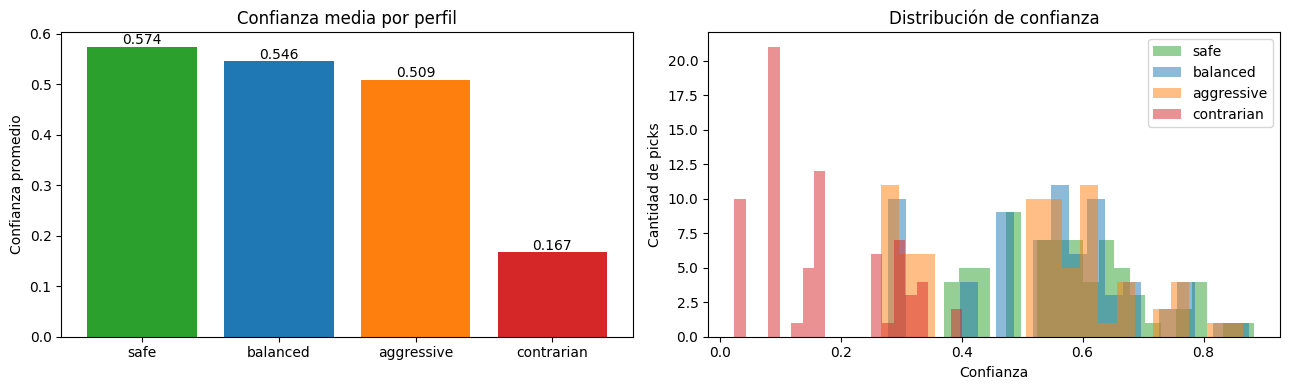

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

means = [sheets[p]['confidence'].mean() for p in PROFILES]
axes[0].bar(PROFILES, means, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
axes[0].set_ylabel('Confianza promedio')
axes[0].set_title('Confianza media por perfil')
for i, m in enumerate(means):
    axes[0].text(i, m + 0.005, f'{m:.3f}', ha='center')

for p, c in zip(PROFILES, ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']):
    axes[1].hist(sheets[p]['confidence'], bins=20, alpha=0.5, label=p, color=c)
axes[1].set_xlabel('Confianza')
axes[1].set_ylabel('Cantidad de picks')
axes[1].set_title('Distribución de confianza')
axes[1].legend()

plt.tight_layout()
plt.show()

## Probabilidades de clasificación a octavos

In [47]:
qual = pd.read_csv(OUTPUTS / 'simulations' / 'tournament_probabilities.csv')
print(f'Total equipos: {len(qual)}')
print()
print('Top 20 con mayor prob de clasificación:')
print(qual.head(20).to_string(index=False))
print()
print('Bottom 10:')
print(qual.tail(10).to_string(index=False))

Total equipos: 48

Top 20 con mayor prob de clasificación:
       team  qualification_prob
      Spain              0.9735
    England              0.9410
  Argentina              0.8960
   Portugal              0.8875
     Brazil              0.8770
     France              0.8715
    Morocco              0.8685
      Japan              0.8640
Switzerland              0.8535
    Germany              0.8370
    Croatia              0.8260
     Canada              0.8200
       Iran              0.8195
    Belgium              0.8130
     Mexico              0.8075
South Korea              0.8030
  Australia              0.8015
   Colombia              0.7995
    Uruguay              0.7855
      Egypt              0.7445

Bottom 10:
              team  qualification_prob
              Iraq              0.4695
             Haiti              0.4590
          Scotland              0.4530
Bosnia-Herzegovina              0.4330
           Curaçao              0.4165
           Czechia     

## Favoritos al título

Total equipos con prob > 0: 47
Suma de probabilidades: 1.0000 (debe ≈ 1.0)

         team  championship_prob
        Spain             0.1285
    Argentina             0.0955
       Brazil             0.0805
       France             0.0630
      England             0.0610
     Portugal             0.0545
      Morocco             0.0510
      Belgium             0.0440
        Japan             0.0395
     Colombia             0.0300
      Germany             0.0285
         Iran             0.0250
  Netherlands             0.0245
      Senegal             0.0225
      Algeria             0.0200
      Croatia             0.0195
        Egypt             0.0175
  South Korea             0.0170
United States             0.0165
       Mexico             0.0155


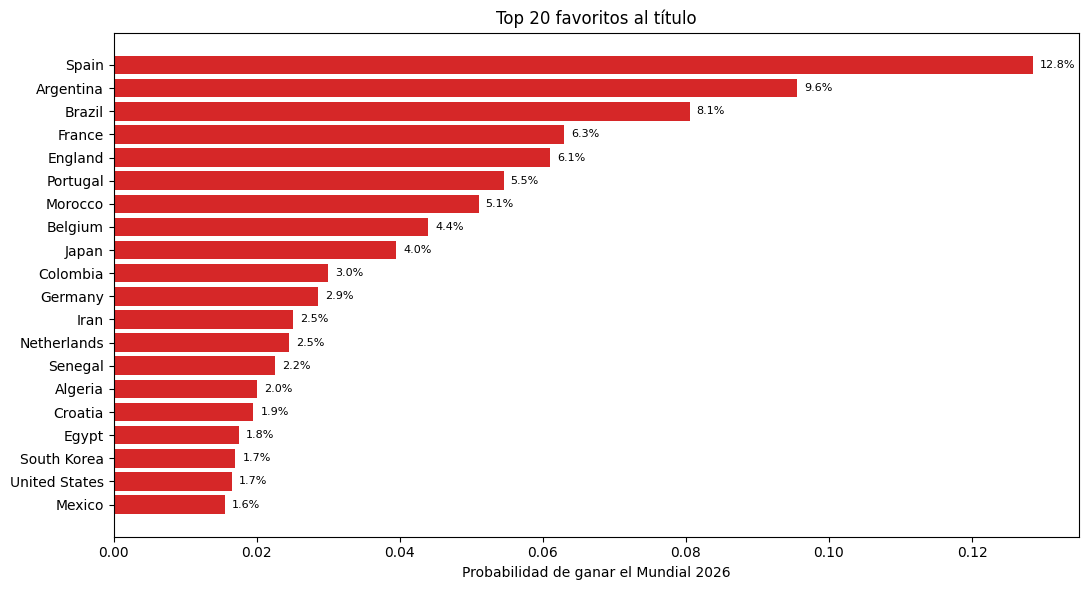

In [48]:
champ = pd.read_csv(OUTPUTS / 'simulations' / 'championship_probabilities.csv')
print(f'Total equipos con prob > 0: {(champ["championship_prob"] > 0).sum()}')
print(f'Suma de probabilidades: {champ["championship_prob"].sum():.4f} (debe ≈ 1.0)')
print()
top20 = champ.head(20)
print(top20.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['team'][::-1], top20['championship_prob'][::-1], color='#d62728')
ax.set_xlabel('Probabilidad de ganar el Mundial 2026')
ax.set_title('Top 20 favoritos al título')
for i, v in enumerate(top20['championship_prob'][::-1]):
    ax.text(v + 0.001, i, f'{v*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Probabilidad de llegar a cada ronda (top 15)

Top 15 favoritos - prob de llegar a cada ronda:
             Octavos  8vos  Cuartos  Semis  Final  Campeón
team                                                      
Spain           35.1  19.2     13.0    9.2    8.0     12.8
Argentina       32.8  20.3     13.2    8.5    5.3      9.6
Brazil          28.6  18.7     14.8   11.6    6.0      8.0
France          35.2  21.0     12.7    7.2    4.8      6.3
England         34.9  21.5     17.2    9.0    5.4      6.1
Portugal        37.6  21.0     14.5    5.8    4.4      5.4
Morocco         32.6  20.3     14.4    9.7    4.6      5.1
Belgium         32.1  22.4     12.4    6.5    3.5      4.4
Japan           36.3  19.5     16.7    5.8    4.2      4.0
Colombia        36.5  21.0     10.6    6.0    2.8      3.0
Germany         37.4  22.0     10.6    7.6    3.2      2.8
Iran            36.2  23.0     11.5    5.4    3.4      2.5
Netherlands     31.2  19.5     12.0    4.4    3.2      2.4
Senegal         37.8  18.2      7.4    4.6    2.5      2.2
Algeria 

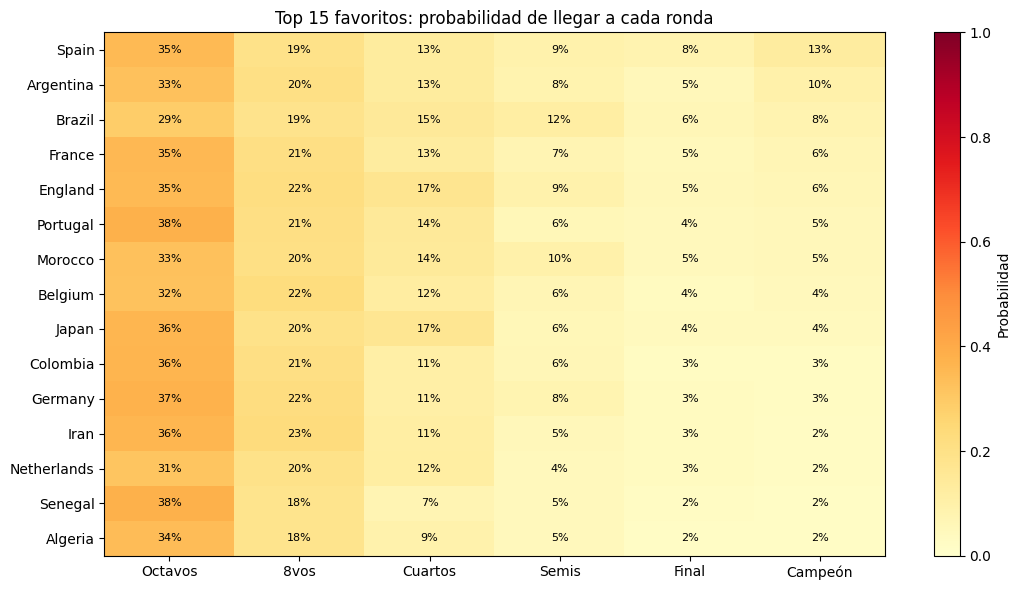

In [49]:
rounds = pd.read_csv(OUTPUTS / 'simulations' / 'round_reached_probabilities.csv')

STAGE_ORDER = ['r32', 'r16', 'qf', 'sf', 'final', 'champion']
STAGE_LABELS = {'r32': 'Octavos', 'r16': '8vos', 'qf': 'Cuartos', 'sf': 'Semis', 'final': 'Final', 'champion': 'Campeón'}

pivot = rounds.pivot_table(index='team', columns='stage', values='prob', aggfunc='max').fillna(0)
pivot = pivot.reindex(columns=[c for c in STAGE_ORDER if c in pivot.columns])
pivot.columns = [STAGE_LABELS.get(c, c) for c in pivot.columns]

top_teams = champ.head(15)['team'].tolist()
pivot_top = pivot.loc[[t for t in top_teams if t in pivot.index]]
print('Top 15 favoritos - prob de llegar a cada ronda:')
print((pivot_top * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_top.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_top.columns)))
ax.set_xticklabels(pivot_top.columns)
ax.set_yticks(range(len(pivot_top.index)))
ax.set_yticklabels(pivot_top.index)
for i in range(len(pivot_top.index)):
    for j in range(len(pivot_top.columns)):
        v = pivot_top.values[i, j]
        if v > 0.01:
            ax.text(j, i, f'{v*100:.0f}%', ha='center', va='center', fontsize=8, color='black' if v < 0.5 else 'white')
fig.colorbar(im, label='Probabilidad')
ax.set_title('Top 15 favoritos: probabilidad de llegar a cada ronda')
plt.tight_layout()
plt.show()

## Distribución de los caminos del bracket (campeones más frecuentes)

In [50]:
paths = pd.read_csv(OUTPUTS / 'simulations' / 'bracket_paths.csv')
print(f'Total simulaciones: {len(paths)}')
print()
print('Combinaciones campeón / subcampeón más frecuentes (top 15):')
top_finals = paths.groupby(['champion', 'runner_up']).size().sort_values(ascending=False).head(15)
print(top_finals.to_string())

Total simulaciones: 2000

Combinaciones campeón / subcampeón más frecuentes (top 15):
champion   runner_up
Spain      England      30
Argentina  Spain        27
           Brazil       26
Spain      Argentina    24
           Portugal     19
           France       19
Argentina  Morocco      18
England    Spain        17
           Japan        17
Brazil     Portugal     17
France     Brazil       16
England    Brazil       16
Brazil     Argentina    16
Portugal   Spain        16
Spain      Colombia     15


## Picks recomendados por perfil (preview)

In [51]:
for p in PROFILES:
    print('=' * 60)
    print(f'  PERFIL: {p.upper()}')
    print('=' * 60)
    cols = ['date', 'team_a', 'team_b', 'pick', 'confidence']
    cols = [c for c in cols if c in sheets[p].columns]
    print(sheets[p][cols].head(12).to_string(index=False))
    print()

  PERFIL: SAFE
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.542292
2026-06-12   South Korea            Czechia    H    0.756078
2026-06-12        Canada Bosnia-Herzegovina    H    0.761880
2026-06-13 United States           Paraguay    H    0.598672
2026-06-13         Qatar        Switzerland    A    0.619785
2026-06-13        Brazil            Morocco    H    0.542292
2026-06-14         Haiti           Scotland    A    0.425696
2026-06-14     Australia             Turkey    H    0.571673
2026-06-14       Germany            Curaçao    H    0.653848
2026-06-14   Netherlands              Japan    A    0.426232
2026-06-14   Ivory Coast            Ecuador    A    0.370144
2026-06-15         Spain Cape Verde Islands    H    0.883315

  PERFIL: BALANCED
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.525903
2026-06-12   South Korea            Czechia    H  

In [23]:
pickel = pd.read_pickle("../models/rating_ensemble.pkl")

In [27]:
print(dir(pickel))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_zscore', 'composite_table', 'elo', 'fit', 'form', 'match_counts', 'pi', 'shrinker', 'weights']


In [33]:
ratings_ordenados = sorted(
    pickel.elo.ratings.items(), 
    key=lambda item: item[1], 
    reverse=True
)

In [34]:
for i, (clave, valor) in enumerate(ratings_ordenados[:30], 1):
    print(f"{i}. {clave}: {valor}")

1. Spain: 1949.8121232912863
2. Argentina: 1929.6423791651364
3. France: 1905.8666442414772
4. England: 1858.7118389984828
5. Brazil: 1841.0336624456086
6. Morocco: 1833.4576937809911
7. Colombia: 1820.1874774862017
8. Portugal: 1819.2873500043709
9. Netherlands: 1817.756844310115
10. Japan: 1817.6400502122897
11. Germany: 1800.6839559412733
12. Ecuador: 1782.9068006567525
13. Croatia: 1782.8751106786149
14. Senegal: 1777.2561088635348
15. Switzerland: 1762.826259747333
16. Uruguay: 1762.8047799497026
17. Mexico: 1760.9865410535383
18. Belgium: 1759.559242883151
19. Iran: 1752.2695944960624
20. Algeria: 1749.165276833254
21. Nigeria: 1741.9730897506788
22. Norway: 1740.4794182875971
23. South Korea: 1739.5540052925269
24. Turkey: 1739.2342711733788
25. Australia: 1736.7084355547227
26. Italy: 1728.555478525999
27. Denmark: 1723.3571982568155
28. Austria: 1715.4344759118535
29. Uzbekistan: 1713.1639050581844
30. Egypt: 1706.6208654876325


# extras que se borrarán

In [36]:
import pickle
from src.prediction.predictor import MatchPredictor
from src.models.base_model import BaseOutcomeModel
from src.utils.io import load_pickle

ensemble = load_pickle("../models/rating_ensemble.pkl")
poisson  = load_pickle("../models/poisson_model.pkl")
elo      = ensemble.elo

predictor = MatchPredictor(
    outcome_models={},          # forza el escenario de la simulación
    poisson_model=poisson,
    elo=elo,
)

pares = [
    ("Spain", "Iraq"),
    ("Brazil", "Saudi Arabia"),
    ("France", "Panama"),
    ("Argentina", "Paraguay"),
    ("Germany", "Norway"),
    ("Paraguay", "Iraq"),       # mid vs mid
]
for a, b in pares:
    # Elo solo
    eh, ed, ea = elo.predict(a, b, neutral=True)
    # Poisson solo
    import pandas as pd
    pp = poisson.predict_proba(pd.DataFrame({"team_a":[a], "team_b":[b]}))[0]
    # Blend final
    bl = predictor.predict_single(a, b)
    print(f"{a:12s} vs {b:18s} | Elo {eh:.2f}/{ed:.2f}/{ea:.2f} | "
          f"Poi {pp[0]:.2f}/{pp[1]:.2f}/{pp[2]:.2f} | "
          f"Blend {bl.p_home:.2f}/{bl.p_draw:.2f}/{bl.p_away:.2f}")


Spain        vs Iraq               | Elo 0.67/0.20/0.13 | Poi 0.15/0.26/0.59 | Blend 0.41/0.23/0.36
Brazil       vs Saudi Arabia       | Elo 0.63/0.21/0.16 | Poi 0.14/0.25/0.61 | Blend 0.39/0.23/0.38
France       vs Panama             | Elo 0.62/0.21/0.17 | Poi 0.13/0.21/0.66 | Blend 0.37/0.21/0.42
Argentina    vs Paraguay           | Elo 0.65/0.20/0.15 | Poi 0.09/0.22/0.69 | Blend 0.37/0.21/0.42
Germany      vs Norway             | Elo 0.44/0.24/0.31 | Poi 0.25/0.25/0.50 | Blend 0.35/0.25/0.41
Paraguay     vs Iraq               | Elo 0.39/0.26/0.35 | Poi 0.46/0.32/0.21 | Blend 0.43/0.29/0.28


In [ ]:
# Top 20 de Poisson attack ratings
print("--- ATTACK ---")
print(sorted(poisson.attack.items(), key=lambda x: -x[1])[:20])
print("--- DEFENSE (más bajo = mejor) ---")
print(sorted(poisson.defense.items(), key=lambda x: x[1])[:20])

--- ATTACK ---


AttributeError: 'PoissonScoreModel' object has no attribute 'attack'

In [39]:
import pandas as pd
df = pd.read_csv("../outputs/simulations/round_reached_probabilities.csv")
print("Stages únicos:", df["stage"].unique())
print("Total filas:", len(df))
print("Filas por stage:", df.groupby("stage").size())


Stages únicos: ['r32']
Total filas: 48
Filas por stage: stage
r32    48
dtype: int64
